In [ ]:
!pip -q install nba_api

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nba_api.stats.endpoints import playergamelogs

In [ ]:
logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season"
).get_data_frames()[0]

In [ ]:
nba_dat = logs[["PLAYER_ID", "PLAYER_NAME", "GAME_DATE", "FTM", "FTA", "FT_PCT"]].copy()

nba_dat["GAME_DATE"] = pd.to_datetime(nba_dat["GAME_DATE"])
nba_dat = nba_dat.sort_values(["PLAYER_ID", "GAME_DATE"])
nba_dat

,PLAYER_ID,PLAYER_NAME,GAME_DATE,FTM,FTA,FT_PCT
26272,2544,LeBron James,2024-10-22,1,1,1.000
25734,2544,LeBron James,2024-10-25,5,8,0.625
25484,2544,LeBron James,2024-10-26,4,4,1.000
25207,2544,LeBron James,2024-10-28,3,6,0.500
24844,2544,LeBron James,2024-10-30,7,7,1.000
...,...,...,...,...,...,...
10667,1642530,Yuki Kawamura,2025-02-03,0,0,0.000
10313,1642530,Yuki Kawamura,2025-02-05,0,0,0.000
9200,1642530,Yuki Kawamura,2025-02-12,0,0,0.000
718,1642530,Yuki Kawamura,2025-04-10,0,0,0.000


In [ ]:
first_n_games = 10
nba_dat_first10 = nba_dat.groupby("PLAYER_ID", group_keys=False).head(first_n_games).copy()
nba_dat_first10

,PLAYER_ID,PLAYER_NAME,GAME_DATE,FTM,FTA,FT_PCT
26272,2544,LeBron James,2024-10-22,1,1,1.000
25734,2544,LeBron James,2024-10-25,5,8,0.625
25484,2544,LeBron James,2024-10-26,4,4,1.000
25207,2544,LeBron James,2024-10-28,3,6,0.500
24844,2544,LeBron James,2024-10-30,7,7,1.000
...,...,...,...,...,...,...
23895,1642530,Yuki Kawamura,2024-11-06,2,2,1.000
23498,1642530,Yuki Kawamura,2024-11-08,0,0,0.000
23156,1642530,Yuki Kawamura,2024-11-10,1,2,0.500
22075,1642530,Yuki Kawamura,2024-11-17,0,0,0.000


In [ ]:
player_ft = (
    nba_dat_first10.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(
        games=("GAME_DATE", "count"),
        ftm=("FTM", "sum"),
        fta=("FTA", "sum")
    )
)
player_ft = player_ft[player_ft["fta"] >= 20].copy()
player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta
0,2544,LeBron James,10,40,49
4,201142,Kevin Durant,10,48,57
8,201566,Russell Westbrook,10,33,47
14,201935,James Harden,10,68,79
15,201939,Stephen Curry,10,33,35
...,...,...,...,...,...
485,1641787,Tosan Evbuomwan,10,18,27
511,1642258,Zaccharie Risacher,10,19,29
512,1642259,Alex Sarr,10,17,24
516,1642264,Stephon Castle,10,16,24


In [ ]:
player_ft["theta_hat_mle"] = player_ft["ftm"] / player_ft["fta"]
player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta,theta_hat_mle
0,2544,LeBron James,10,40,49,0.816327
4,201142,Kevin Durant,10,48,57,0.842105
8,201566,Russell Westbrook,10,33,47,0.702128
14,201935,James Harden,10,68,79,0.860759
15,201939,Stephen Curry,10,33,35,0.942857
...,...,...,...,...,...,...
485,1641787,Tosan Evbuomwan,10,18,27,0.666667
511,1642258,Zaccharie Risacher,10,19,29,0.655172
512,1642259,Alex Sarr,10,17,24,0.708333
516,1642264,Stephon Castle,10,16,24,0.666667


In [ ]:
mu = player_ft["ftm"].sum() / player_ft["fta"].sum()
sigma2_hat = np.mean(player_ft["theta_hat_mle"] * (1 - player_ft["theta_hat_mle"]) / player_ft["fta"])

In [ ]:
n = len(player_ft)
z = player_ft["theta_hat_mle"] - mu

In [ ]:
B = ((n - 2) * sigma2_hat) / np.sum(z**2)
B

np.float64(0.45587346470138596)

In [ ]:
B = max(0, min(B, 1))
B

np.float64(0.45587346470138596)

In [ ]:
player_ft["theta_hat_js"] = mu + (1 - B) * (player_ft["theta_hat_mle"] - mu)
player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta,theta_hat_mle,theta_hat_js
0,2544,LeBron James,10,40,49,0.816327,0.801026
4,201142,Kevin Durant,10,48,57,0.842105,0.815053
8,201566,Russell Westbrook,10,33,47,0.702128,0.738888
14,201935,James Harden,10,68,79,0.860759,0.825204
15,201939,Stephen Curry,10,33,35,0.942857,0.869875
...,...,...,...,...,...,...,...
485,1641787,Tosan Evbuomwan,10,18,27,0.666667,0.719592
511,1642258,Zaccharie Risacher,10,19,29,0.655172,0.713338
512,1642259,Alex Sarr,10,17,24,0.708333,0.742264
516,1642264,Stephon Castle,10,16,24,0.666667,0.719592


In [ ]:
player_ft["shrink_amount"] = player_ft["theta_hat_mle"] - player_ft["theta_hat_js"]
player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta,theta_hat_mle,theta_hat_js,shrink_amount
0,2544,LeBron James,10,40,49,0.816327,0.801026,0.015300
4,201142,Kevin Durant,10,48,57,0.842105,0.815053,0.027052
8,201566,Russell Westbrook,10,33,47,0.702128,0.738888,-0.036760
14,201935,James Harden,10,68,79,0.860759,0.825204,0.035556
15,201939,Stephen Curry,10,33,35,0.942857,0.869875,0.072982
...,...,...,...,...,...,...,...,...
485,1641787,Tosan Evbuomwan,10,18,27,0.666667,0.719592,-0.052926
511,1642258,Zaccharie Risacher,10,19,29,0.655172,0.713338,-0.058166
512,1642259,Alex Sarr,10,17,24,0.708333,0.742264,-0.033931
516,1642264,Stephon Castle,10,16,24,0.666667,0.719592,-0.052926


In [ ]:
results = player_ft[[
    "PLAYER_NAME", "games", "ftm", "fta",
    "theta_hat_mle", "theta_hat_js", "shrink_amount"
]].copy()

results = results.sort_values("theta_hat_mle", ascending=False)

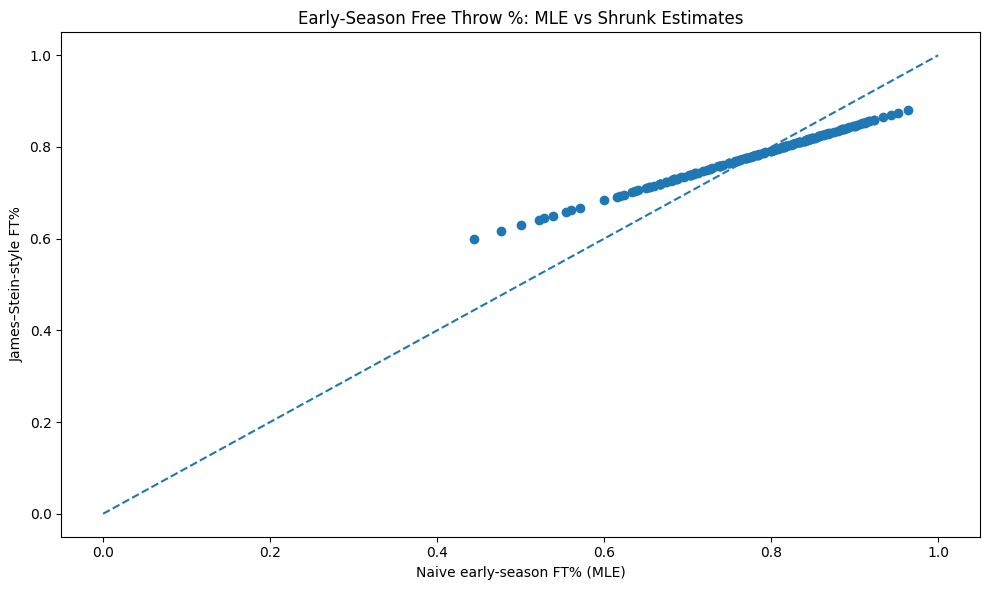

In [ ]:
plot_df = results.sort_values("theta_hat_mle").copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["theta_hat_mle"], plot_df["theta_hat_js"])
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Naive early-season FT% (MLE)")
plt.ylabel("James–Stein-style FT%")
plt.title("Early-Season Free Throw %: MLE vs Shrunk Estimates")
plt.tight_layout()
plt.show()

In [ ]:
season_ft = (
    nba_dat.groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .agg(
        ftm_season=("FTM", "sum"),
        fta_season=("FTA", "sum")
    )
)

season_ft["theta_true"] = season_ft["ftm_season"] / season_ft["fta_season"]


player_ft = player_ft.merge(
    season_ft[["PLAYER_ID", "theta_true"]],
    on="PLAYER_ID",
    how="left"
)

player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta,theta_hat_mle,theta_hat_js,shrink_amount,theta_true_x,theta_true_y,theta_true
0,2544,LeBron James,10,40,49,0.816327,0.801026,0.015300,0.782477,0.782477,0.782477
1,201142,Kevin Durant,10,48,57,0.842105,0.815053,0.027052,0.839335,0.839335,0.839335
2,201566,Russell Westbrook,10,33,47,0.702128,0.738888,-0.036760,0.660944,0.660944,0.660944
3,201935,James Harden,10,68,79,0.860759,0.825204,0.035556,0.873702,0.873702,0.873702
4,201939,Stephen Curry,10,33,35,0.942857,0.869875,0.072982,0.933110,0.933110,0.933110
...,...,...,...,...,...,...,...,...,...,...,...
153,1641787,Tosan Evbuomwan,10,18,27,0.666667,0.719592,-0.052926,0.753425,0.753425,0.753425
154,1642258,Zaccharie Risacher,10,19,29,0.655172,0.713338,-0.058166,0.711409,0.711409,0.711409
155,1642259,Alex Sarr,10,17,24,0.708333,0.742264,-0.033931,0.678788,0.678788,0.678788
156,1642264,Stephon Castle,10,16,24,0.666667,0.719592,-0.052926,0.723837,0.723837,0.723837


In [ ]:
player_ft["truep-jsp"] = player_ft["theta_true"]-player_ft["theta_hat_js"]
player_ft

,PLAYER_ID,PLAYER_NAME,games,ftm,fta,theta_hat_mle,theta_hat_js,shrink_amount,theta_true_x,theta_true_y,theta_true,truep-jsp
0,2544,LeBron James,10,40,49,0.816327,0.801026,0.015300,0.782477,0.782477,0.782477,-0.018549
1,201142,Kevin Durant,10,48,57,0.842105,0.815053,0.027052,0.839335,0.839335,0.839335,0.024282
2,201566,Russell Westbrook,10,33,47,0.702128,0.738888,-0.036760,0.660944,0.660944,0.660944,-0.077944
3,201935,James Harden,10,68,79,0.860759,0.825204,0.035556,0.873702,0.873702,0.873702,0.048499
4,201939,Stephen Curry,10,33,35,0.942857,0.869875,0.072982,0.933110,0.933110,0.933110,0.063235
...,...,...,...,...,...,...,...,...,...,...,...,...
153,1641787,Tosan Evbuomwan,10,18,27,0.666667,0.719592,-0.052926,0.753425,0.753425,0.753425,0.033832
154,1642258,Zaccharie Risacher,10,19,29,0.655172,0.713338,-0.058166,0.711409,0.711409,0.711409,-0.001929
155,1642259,Alex Sarr,10,17,24,0.708333,0.742264,-0.033931,0.678788,0.678788,0.678788,-0.063477
156,1642264,Stephon Castle,10,16,24,0.666667,0.719592,-0.052926,0.723837,0.723837,0.723837,0.004245


In [ ]:
player_ft["sq_error_mle"] = (player_ft["theta_hat_mle"] - player_ft["theta_true"])**2
player_ft["sq_error_js"] = (player_ft["theta_hat_js"] - player_ft["theta_true"])**2

mse_mle = player_ft["sq_error_mle"].mean()
mse_js = player_ft["sq_error_js"].mean()

print("MSE of MLE:", mse_mle)
print("MSE of JS:", mse_js)

MSE of MLE: 0.003931212527525573
MSE of JS: 0.002367831197733512
